![alt text](image.png)


## Data Cleaning and Insight Generation from Survey 


This code is my take on the Task 4 of the Elevvo Pathways Data Analyst Internship program. In this notebook, I shall process data from the dataset kaggle_servery_2017_2021.csv from the Kaggle Data Science survey pages. 



In [1]:
import pandas as pd         
import numpy as np         
import matplotlib.pyplot as plt  
import seaborn as sns             
from sklearn.preprocessing import LabelEncoder 
import plotly.express as px     
import plotly.graph_objects as go 
from dash import Dash, dcc, html


Here, we do an initial check of the dataset.

In [2]:
df = pd.read_csv(
    'kaggle_survey_2017_2021.csv',
    header=1,        
    encoding='utf-8',
    low_memory=False
)
    
df.columns = df.columns.str.strip()

df.rename(columns={'-': 'Year'}, inplace=True)

print("Unique values in 'Year' column:", df['Year'].unique())

df['Year'] = df['Year'].astype(str).str.strip()

df_2021 = df[df['Year'] == '2021'].copy()

df_2021.reset_index(drop=True, inplace=True)

print("\nShape of 2021 dataset:", df_2021.shape)
print("\nColumns:\n", df_2021.columns)
print("\nFirst 5 rows:\n", df_2021.head())
print("\nData types:\n")
df_2021.info()


Unique values in 'Year' column: [2021 2020 2019 2018 2017]

Shape of 2021 dataset: (25973, 293)

Columns:
 Index(['Year', 'Duration (in seconds)', 'What is your age (# years)?',
       'What is your gender? - Selected Choice',
       'In which country do you currently reside?',
       'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?',
       'Select the title most similar to your current role (or most recent title if retired): - Selected Choice',
       'For how many years have you been writing code and/or programming?',
       'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - Python',
       'What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - R',
       ...
       'In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice -  Ne

Now, we move onto the next step of preparing the Kaggle Survey dataset to focus only on the 2021 responses. We will apply the following steps:  

- **Loading the dataset properly**  
 We use pd.read_csv with header=1 to skip the extra header row, encoding='utf-8' to handle special characters, and low_memory=False to avoid mixed type warnings for large datasets. 

- **Cleaning column names**  
We strip any leading or trailing whitespace from column names and rename the first column '-' to 'Year' for clarity. 

- **Filtering 2021 responses**  
We filter the dataset to include only rows where the Year column is 2021 and reset the index to clean up row numbering. This ensures we focus only on the latest survey data.

- **Overview of the 2021 dataset**  
Shape: (25973, 293) → 25,973 respondents, 293 columns.

- **Why we filter only 2021**  
  Focusing on the latest year allows us to analyze current trends in programming, tools, and data science practices without inconsistencies from older survey years.

Columns: Include demographics (age, gender, country, education), coding experience, programming languages, tools used, and multi-choice responses.
Data types: Mostly object (text), with some numeric columns like Duration (in seconds).

We shall now begin cleaning the dataset for further use. 

In [4]:
# checking missing values
missing_values = df_2021.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_values / len(df_2021)) * 100

# Combining dataframes
missing_data = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

# to display top 20 columns with missing data
print(missing_data.head(20))


                                                    Missing Values  Percentage
In the next 2 years, do you hope to become more...           25973       100.0
Which of the following business intelligence to...           25973       100.0
Which of the following hosted notebook products...           25973       100.0
Which of the following integrated development e...           25973       100.0
What programming languages do you use on a regu...           25973       100.0
Which types of specialized hardware do you use ...           25973       100.0
What data visualization libraries or tools do y...           25973       100.0
Which of the following natural language process...           25973       100.0
Which of the following big data products (relat...           25973       100.0
Which of the following ML algorithms do you use...           25973       100.0
Which of the following machine learning framewo...           25973       100.0
Which types of specialized hardware do you use ...  

From the above output, we can see that the top 20 columns have 100% missing values, making them irrelevant for our analysis. Therefore, we will remove these columns to keep only meaningful data in our dataset.

In [5]:
df_2021_cleaned = df_2021.dropna(axis=1, how='all')

print("Shape after removing empty columns:", df_2021_cleaned.shape)

Shape after removing empty columns: (25973, 272)


In [9]:
threshold = 50.0
missing_data = df_2021.isnull().mean() * 100
cols_to_drop = missing_data[missing_data > threshold].index
df_2021.drop(columns=cols_to_drop, inplace=True, errors='ignore')


After removing the majority of missing rows, the next step is to fill in the remaining missing values. For numerical columns, we can use the mean or median, while for categorical columns, we can use the mode or a constant placeholder.

In [10]:
numerical_cols = df_2021.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    df_2021[col].fillna(df_2021[col].median(), inplace=True)

categorical_cols = df_2021.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_2021[col].fillna(df_2021[col].mode()[0], inplace=True)

C:\Users\yashs\AppData\Local\Temp\ipykernel_13276\2767630293.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_2021[col].fillna(df_2021[col].median(), inplace=True)
C:\Users\yashs\AppData\Local\Temp\ipykernel_13276\2767630293.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


The next step would be to deal with duplicates and outliers, removing them will make our dataset more appropriate to use. 

In [4]:
duplicate_rows = df_2021[df_2021.duplicated()]
print(f"Number of duplicate rows: {len(duplicate_rows)}")

df_2021 = df_2021.drop_duplicates()

numerical_cols = df_2021.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    Q1 = df_2021[col].quantile(0.25)
    Q3 = df_2021[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_2021[(df_2021[col] < lower_bound) | (df_2021[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")


Number of duplicate rows: 0
Duration (in seconds): 3152 outliers
What programming languages do you use on a regular basis? (Select all that apply) - Selected Choice - None: 0 outliers
Which of the following integrated development environments (IDE's) do you use on a regular basis?  (Select all that apply) - Selected Choice - None: 0 outliers
Which of the following hosted notebook products do you use on a regular basis?  (Select all that apply) - Selected Choice - None: 0 outliers
What data visualization libraries or tools do you use on a regular basis?  (Select all that apply) - Selected Choice - None: 0 outliers
Which of the following machine learning frameworks do you use on a regular basis? (Select all that apply) - Selected Choice - None: 0 outliers
Which of the following ML algorithms do you use on a regular basis? (Select all that apply): - Selected Choice - None: 0 outliers
Which categories of computer vision methods do you use on a regular basis?  (Select all that apply) - Sele

We will handle outliers now in the next few lines. 

In [4]:
col = 'Duration (in seconds)'
Q1 = df_2021[col].quantile(0.25)
Q3 = df_2021[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = max(0, Q1 - 1.5 * IQR) 
upper_bound = Q3 + 1.5 * IQR

# Capping values
df_2021[col] = df_2021[col].clip(lower_bound, upper_bound)

print(f"Outliers in '{col}' have been capped between {lower_bound:.2f} and {upper_bound:.2f}")


Outliers in 'Duration (in seconds)' have been capped between 0.00 and 1930.50


Next, we will standardize data, for example categorical tables into numerical format, for it to be more appropriate during analysis. 

In [5]:
# selecting key categorical columns for encoding
categorical_cols = [
    'What is your gender? - Selected Choice',
    'In which country do you currently reside?',
    'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?',
    'Select the title most similar to your current role (or most recent title if retired): - Selected Choice'
]

label_encoder = LabelEncoder()

for col in categorical_cols:
    if col in df_2021.columns:
        df_2021[col] = label_encoder.fit_transform(df_2021[col].astype(str))

print("Categorical columns encoded successfully.")


Categorical columns encoded successfully.


Through these steps, we have successfully done the following for our dataset:

- Loaded dataset → Read CSV, renamed first column to Year, filtered for 2021 responses.

- Removed empty columns → Dropped columns with 100% missing values.

- Dropped high-missing columns → Removed columns with more than 50% missing data.

- Filled missing values → Median for numeric columns, mode for categorical columns.

- Checked duplicates → Found none.

- Detected outliers → Used IQR method.

- Handled outliers → Capped extreme values in Duration (in seconds).

- Encoded categorical columns → Applied label encoding on key fields.



Moving on, we will now start the Exploratory Data Analysis. Below are the tasks we will perform in this section: 

- Understand the data → Summarize key statistics (mean, median, mode, etc.).

- Univariate Analysis → Analyze individual features (e.g., distribution of age, duration).

- Bivariate Analysis → Explore relationships (e.g., programming language vs. job role).

- Visualizations → Use bar charts, histograms, and pie charts for better insights.

- Detect Patterns → Identify trends like most popular languages, tools, etc.

Overall Dataset summary

In [7]:
print("Basic Information:")
print(df_2021.info())

print("\nStatistical Summary (Numerical Columns):")
print(df_2021.describe())

print("\nTop Categorical Columns Value Counts:")
categorical_cols = df_2021.select_dtypes(include=['object']).columns

for col in categorical_cols[:5]:  
    print(f"\nColumn: {col}")
    print(df_2021[col].value_counts().head(10))


Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25973 entries, 0 to 25972
Columns: 293 entries, Year to In the next 2 years, do you hope to become more familiar with any of these tools for managing ML experiments? (Select all that apply) - Selected Choice - Other
dtypes: float64(18), int64(4), object(271)
memory usage: 58.1+ MB
None

Statistical Summary (Numerical Columns):
       Duration (in seconds)  What is your gender? - Selected Choice  \
count           25973.000000                            25973.000000   
mean              827.629538                                0.788665   
std               531.887886                                1.569419   
min               120.000000                                0.000000   
25%               443.000000                                0.000000   
50%               656.000000                                0.000000   
75%              1038.000000                                0.000000   
max              1930.5000

 Univariate Analysis

- **Numerical Columns:** Plotted histograms and boxplots to visualize the distribution and identify potential outliers.  
- **Categorical Columns:** Plotted bar charts of top categories to understand the frequency of different values.


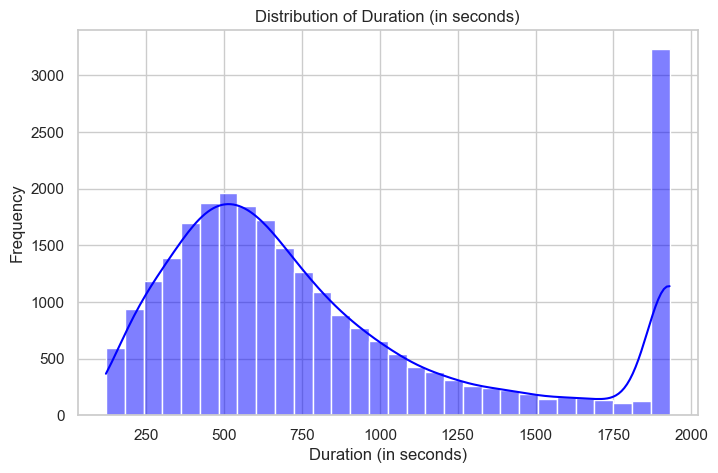

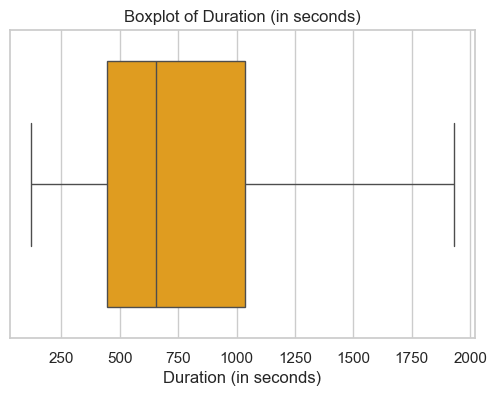

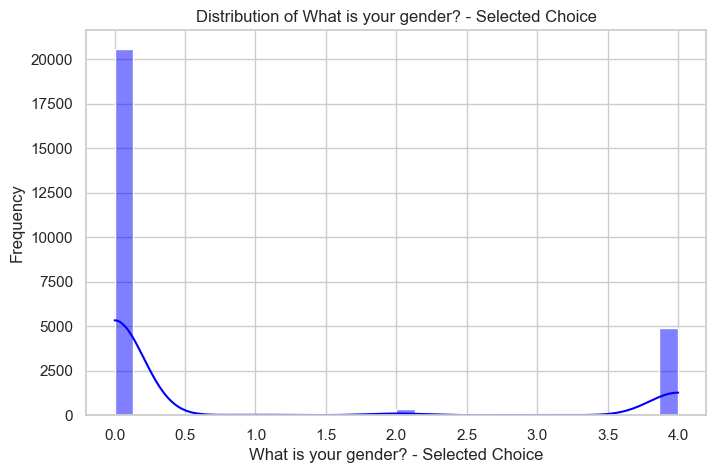

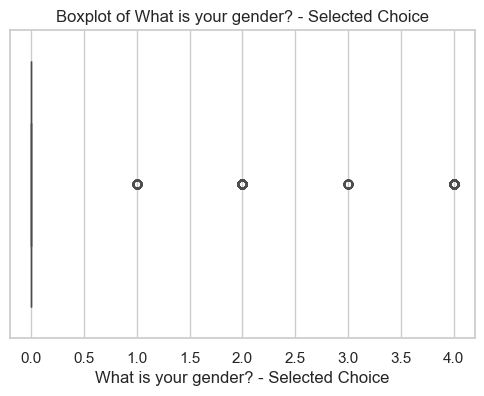

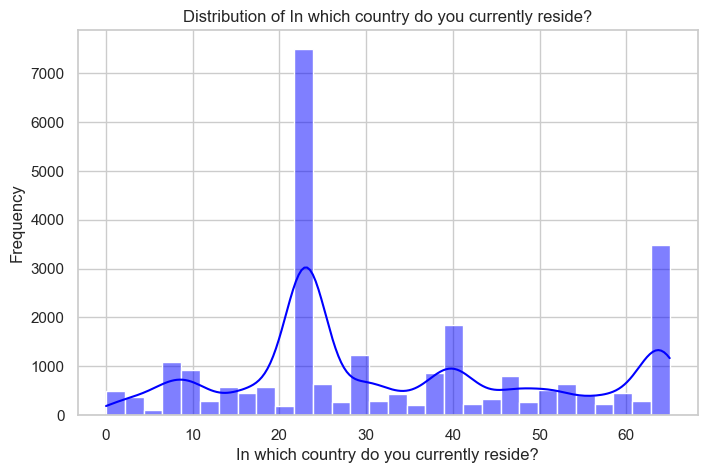

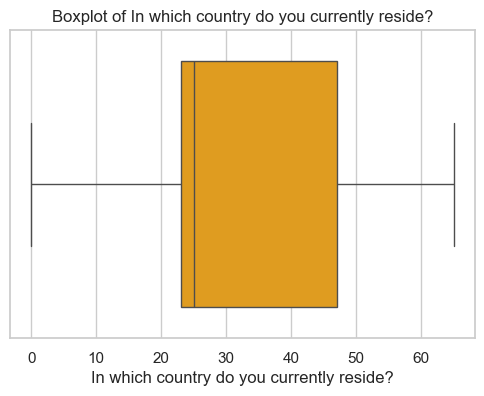

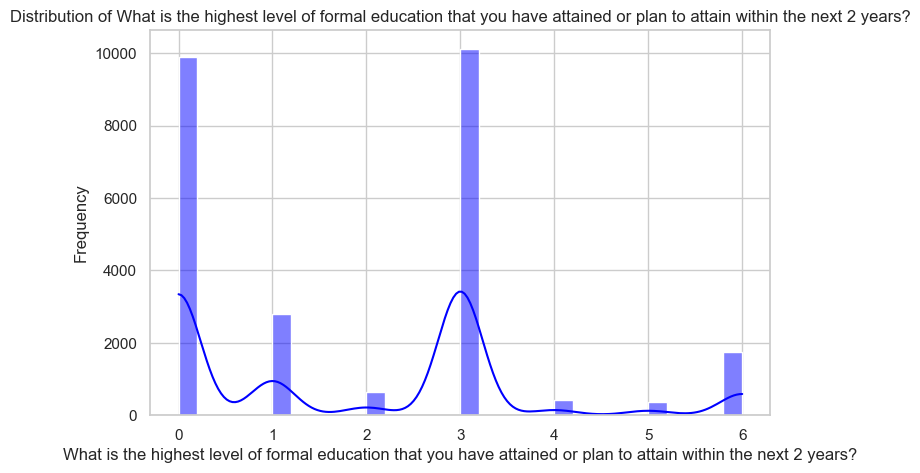

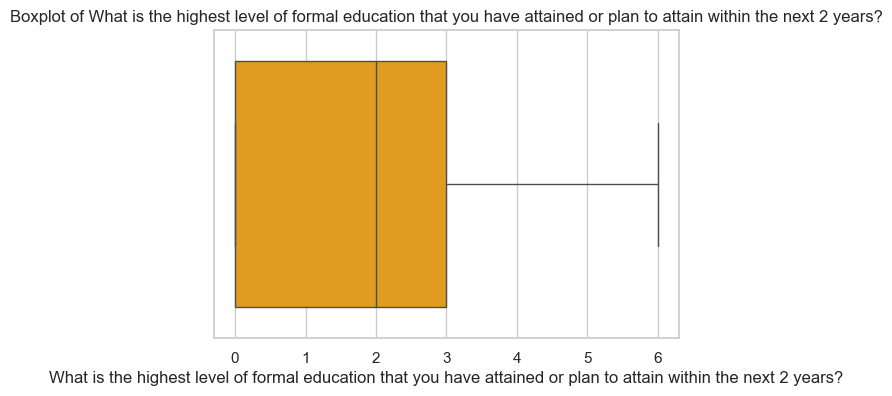

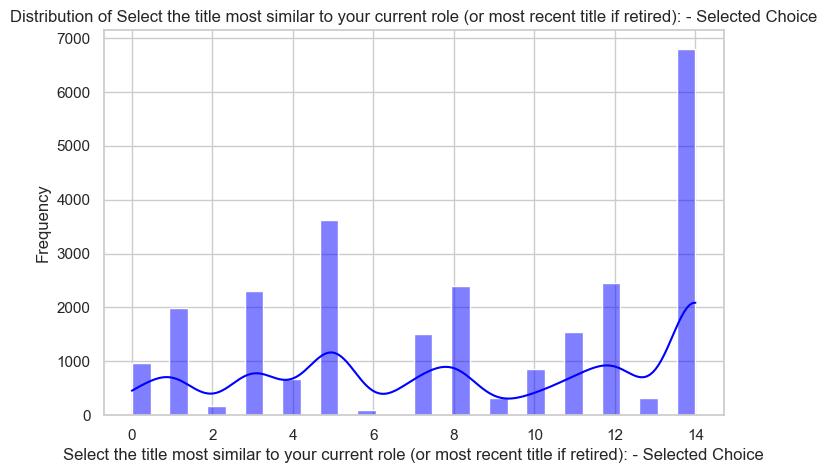

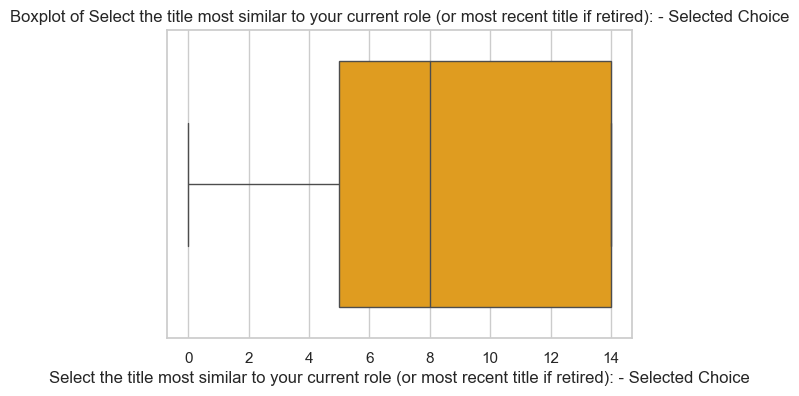

In [14]:
# cleaning column names
df_2021.columns = df_2021.columns.str.strip().str.replace('\n', ' ').str.replace('\r', '')

# identifying numerical columns
numerical_cols = df_2021.select_dtypes(include=['int64', 'float64']).columns

# plotting histograms and boxplots
for col in numerical_cols:
    # Ensure numeric
    df_2021[col] = pd.to_numeric(df_2021[col], errors='coerce')
    
    # Skip columns with all NaN values
    if df_2021[col].dropna().empty:
        continue

    # Histogram
    plt.figure(figsize=(8, 5))
    sns.histplot(df_2021[col], bins=30, kde=True, color='blue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    
    # Boxplot
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_2021[col].dropna(), color='orange')
    plt.title(f"Boxplot of {col}")
    plt.show()


 Bivariate Analysis

- Age vs Duration: Scatter plot to analyze whether older respondents take more or less time to complete the survey.

- Gender vs Duration: Boxplot to compare completion time across genders.

- Education Level vs Duration: Boxplot to see if education level impacts the survey completion time.

- Age vs Current Role: Countplot to observe the distribution of job roles across different age groups.

- Correlation Heatmap: Displays correlation between numerical variables like Age and Duration to identify relationships.

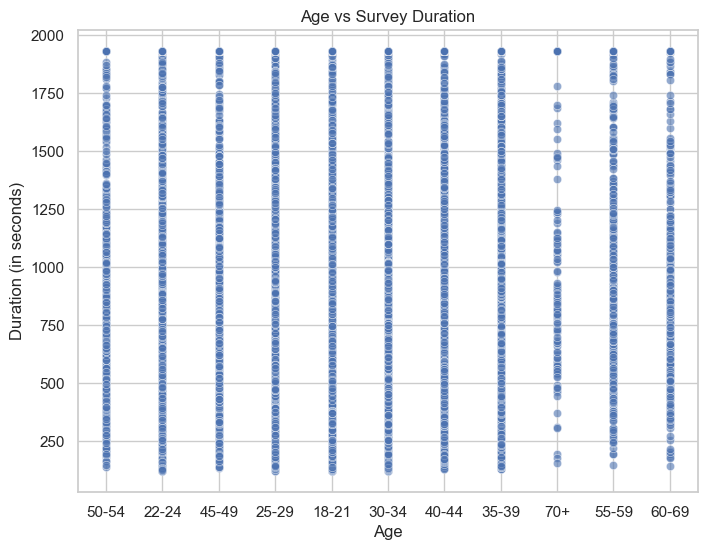

C:\Users\yashs\AppData\Local\Temp\ipykernel_16132\2877877651.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2021, x='What is your gender? - Selected Choice', y='Duration (in seconds)', palette='pastel')


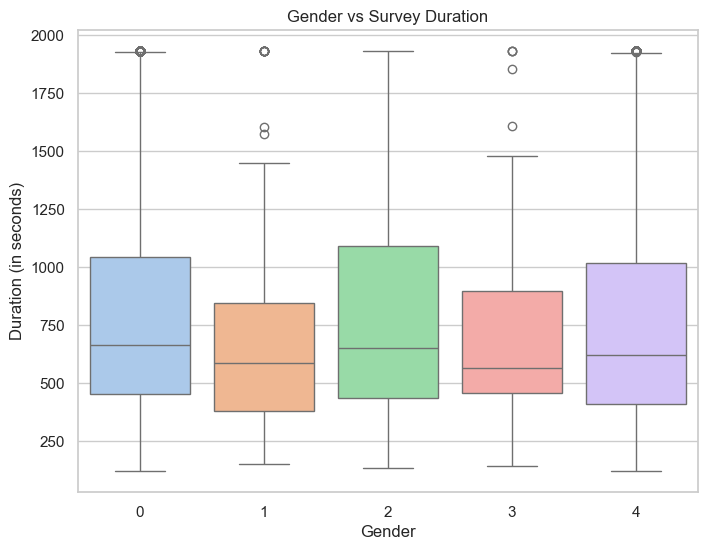

C:\Users\yashs\AppData\Local\Temp\ipykernel_16132\2877877651.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2021,


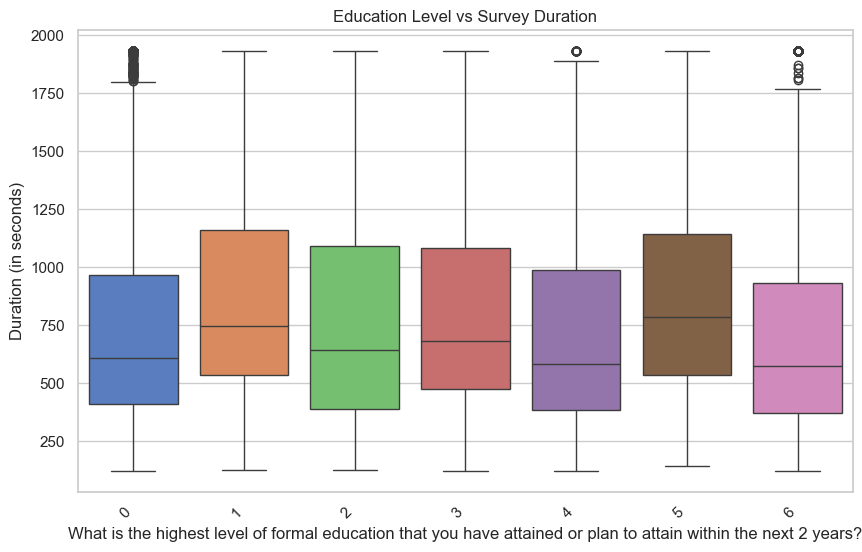

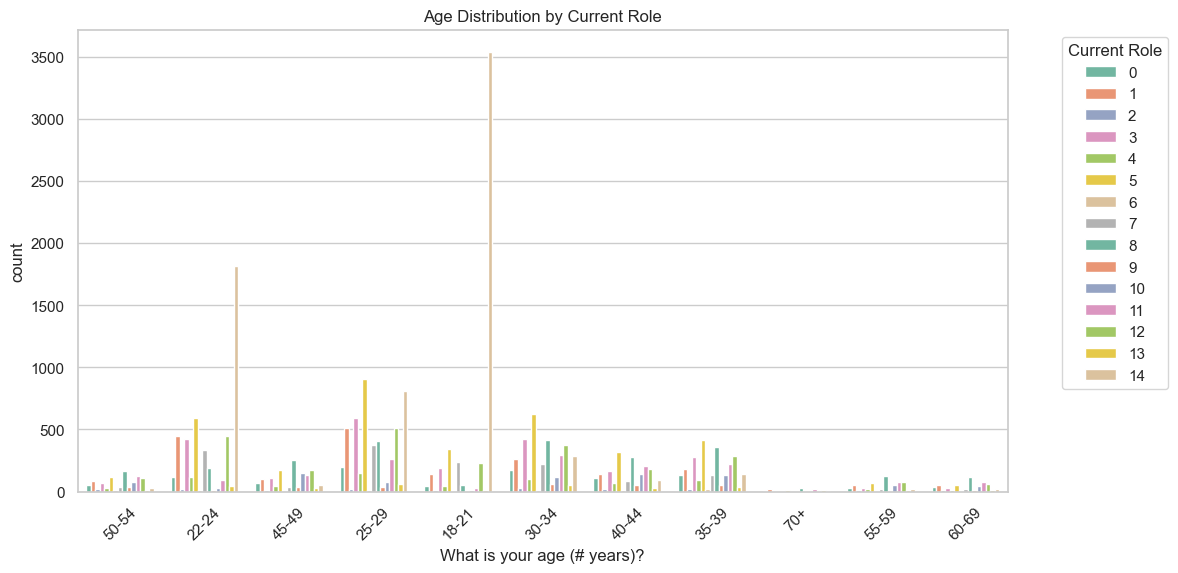

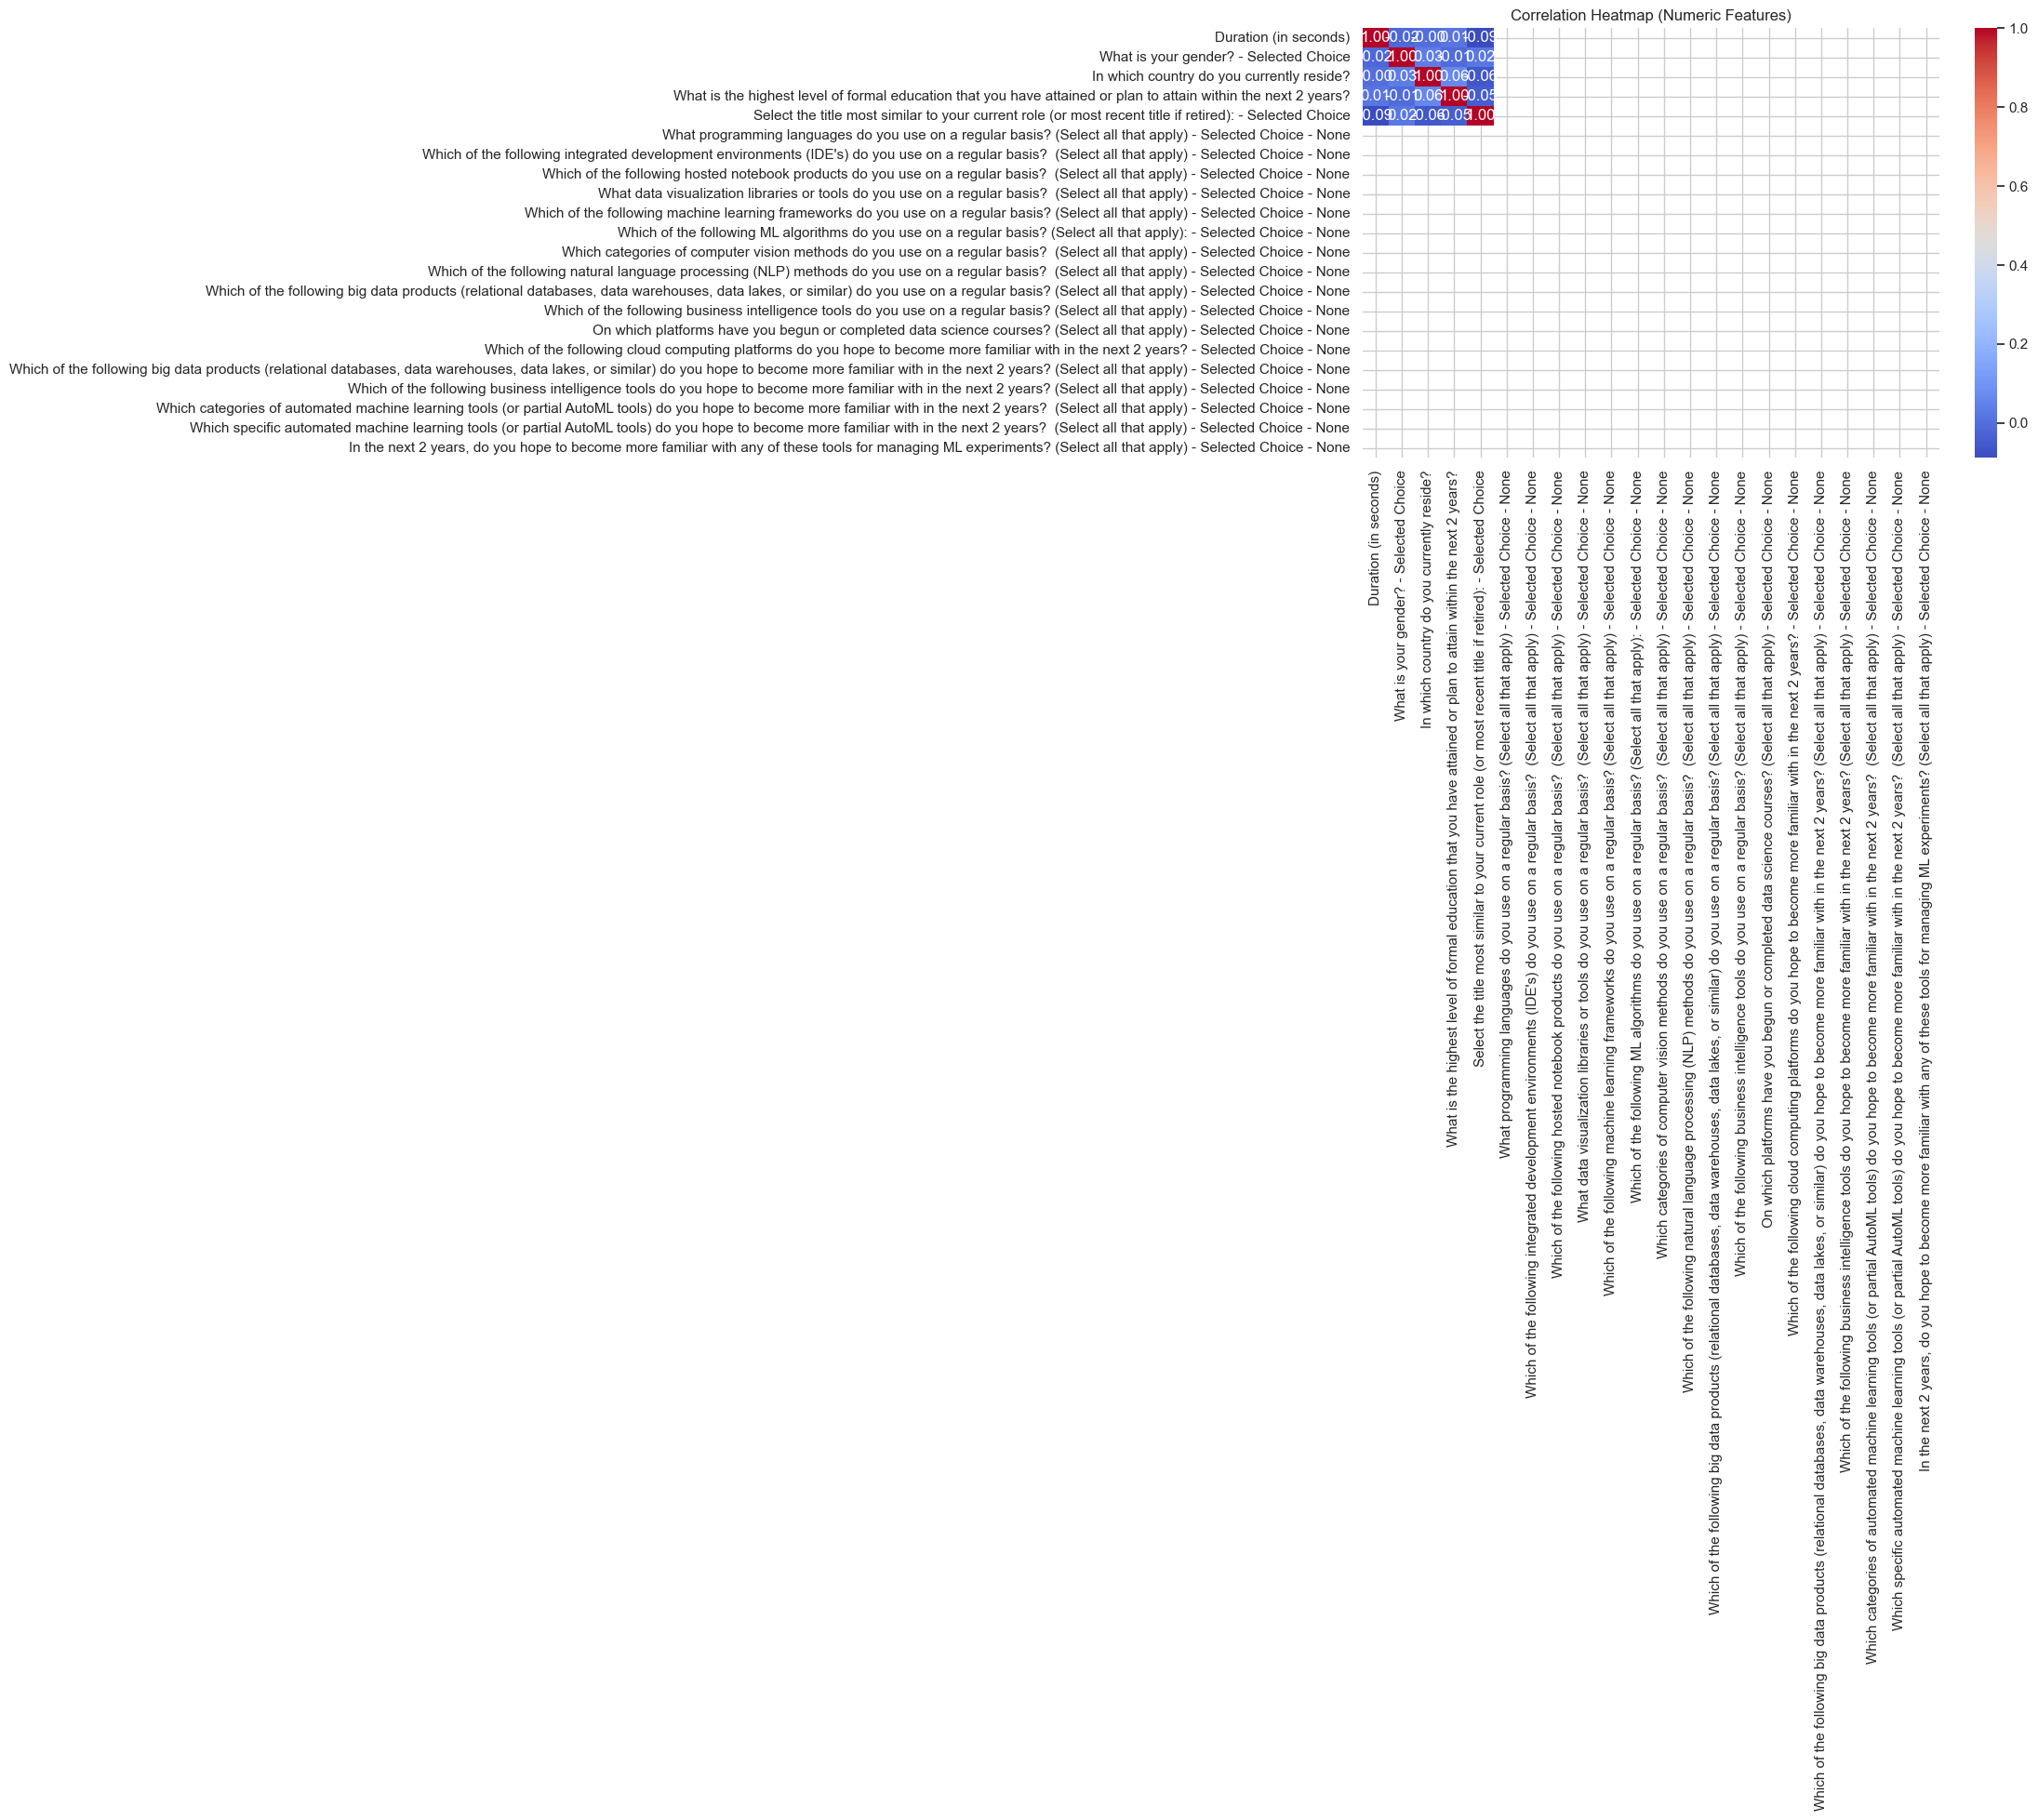

In [15]:
# 1. Relationship between Age and Duration
if 'Duration (in seconds)' in df_2021.columns and 'What is your age (# years)?' in df_2021.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_2021, x='What is your age (# years)?', y='Duration (in seconds)', alpha=0.6)
    plt.title("Age vs Survey Duration")
    plt.xlabel("Age")
    plt.ylabel("Duration (in seconds)")
    plt.show()

# 2. Gender vs Duration (Boxplot)
if 'Duration (in seconds)' in df_2021.columns and 'What is your gender? - Selected Choice' in df_2021.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=df_2021, x='What is your gender? - Selected Choice', y='Duration (in seconds)', palette='pastel')
    plt.title("Gender vs Survey Duration")
    plt.xlabel("Gender")
    plt.ylabel("Duration (in seconds)")
    plt.show()

# 3. Education Level vs Duration (Boxplot)
if 'Duration (in seconds)' in df_2021.columns and 'What is the highest level of formal education that you have attained or plan to attain within the next 2 years?' in df_2021.columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_2021, 
                x='What is the highest level of formal education that you have attained or plan to attain within the next 2 years?', 
                y='Duration (in seconds)', 
                palette='muted')
    plt.title("Education Level vs Survey Duration")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Duration (in seconds)")
    plt.show()

# 4. Age vs Current Role (Bar plot for counts)
if 'What is your age (# years)?' in df_2021.columns and 'Select the title most similar to your current role (or most recent title if retired): - Selected Choice' in df_2021.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_2021, 
                  x='What is your age (# years)?', 
                  hue='Select the title most similar to your current role (or most recent title if retired): - Selected Choice', 
                  palette='Set2')
    plt.title("Age Distribution by Current Role")
    plt.xticks(rotation=45)
    plt.legend(title="Current Role", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# 5. Correlation Heatmap for Numeric Variables
numeric_cols = df_2021.select_dtypes(include=['int64', 'float64']).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10, 6))
    corr = df_2021[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.show()


The visualizations help us understand how different respondent characteristics relate to survey engagement and other numeric patterns.

We can see how factors like age, gender, education, and current role influence the time respondents took to complete the survey.

Scatterplots, boxplots, and bar charts highlight these patterns, while the correlation heatmap shows how numeric variables relate to each other.

Overall, these plots give a clear picture of respondent behavior, engagement, and trends across the survey.

### Conclusion

By performing univariate and bivariate analysis on the Kaggle Data Science Survey 2017–2021 dataset, we explored respondent demographics, education, roles, and survey engagement. Key patterns were identified across age, gender, education level, and job roles, along with relationships between numeric variables highlighted by the correlation heatmap. These insights provide a clear understanding of respondent behavior, learning preferences, and professional trends, offering valuable guidance for data-driven decisions in education, training, and workforce planning.


Bonus: Create a summary dashboard or chart showing top 5 insights

In [9]:
# 1. Top Programming Languages
language_cols = [col for col in df_2021.columns if 'Python' in col or 'SQL' in col or 'C++' in col or 'Java' in col or 'R' in col]
language_counts = {}

for col in language_cols:
    language_name = col.split('-')[-1].strip() if '-' in col else col
    language_counts[language_name] = df_2021[col].notnull().sum()

top_languages = pd.Series(language_counts).sort_values(ascending=False).head(5)
print("Top 5 Programming Languages:")
print(top_languages)


# 2. Top Learning Methods
learning_cols = [col for col in df_2021.columns if 'learn' in col.lower() and 'data science' in col.lower()]
learning_counts = {}

for col in learning_cols:
    method_name = col.split('-')[-1].strip() if '-' in col else col
    learning_counts[method_name] = df_2021[col].notnull().sum()

top_learning_methods = pd.Series(learning_counts).sort_values(ascending=False).head(5)
print("\nTop 5 Learning Methods:")
print(top_learning_methods)


# 3. Top Job Roles
role_col = [col for col in df_2021.columns if 'current role' in col.lower() or 'title' in col.lower()]
if role_col:
    top_job_roles = df_2021[role_col[0]].value_counts().head(5)
    print("\nTop 5 Job Roles:")
    print(top_job_roles)
else:
    print("\nNo job role column found!")


# 4. Top Tools
tools_cols = [col for col in df_2021.columns if 'Matplotlib' in col or 'Seaborn' in col or 'Plotly' in col or 'Tableau' in col or 'PowerBI' in col]
tools_counts = {}

for col in tools_cols:
    tool_name = col.split('-')[-1].strip() if '-' in col else col
    tools_counts[tool_name] = df_2021[col].notnull().sum()

top_tools = pd.Series(tools_counts).sort_values(ascending=False).head(5)
print("\nTop 5 Tools:")
print(top_tools)


# 5. Experience
experience_cols = [col for col in df_2021.columns if 'years' in col.lower() and 'code' in col.lower()]
experience_counts = {}

for col in experience_cols:
    exp_name = col.split('-')[-1].strip() if '-' in col else col
    # Count non-null entries per experience year
    experience_counts[exp_name] = df_2021[col].notnull().sum()

# converting to Series and sorting by year if numeric, otherwise by counts
if experience_counts:
    top_experience = pd.Series(experience_counts).sort_index()
    print("\nExperience Levels (Years Coding):")
    print(top_experience)
else:
    print("\nNo experience column found!")



Top 5 Programming Languages:
Python                              21860
Linear or Logistic Regression       13852
Decision Trees or Random Forests    11863
SQL                                 10756
MySQL                                6135
dtype: int64

Top 5 Learning Methods:
Kaggle Learn Courses               8670
Reddit (r/machinelearning, etc)    2939
LinkedIn Learning                  2693
dtype: int64

Top 5 Job Roles:
Select the title most similar to your current role (or most recent title if retired): - Selected Choice
Student              6804
Data Scientist       3616
Software Engineer    2449
Other                2393
Data Analyst         2301
Name: count, dtype: int64

Top 5 Tools:
Matplotlib                 17595
Seaborn                    12586
Plotly / Plotly Express     5778
Tableau                     5421
Plotly Dash                  293
dtype: int64

Experience Levels (Years Coding):
For how many years have you been writing code and/or programming?    25973
dtype: int